In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import string
import nltk
from nltk.corpus import stopwords


# Télécharger les stopwords français

In [ ]:
nltk.download("stopwords")
stop_words = set(stopwords.words("french"))

# Charger les datasets

In [4]:
file1 = "Data/intent-detection-train.csv"
file2 = "Data/intent-detection-augmented.csv"
df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)

# Aperçu des datasets

In [7]:
def overview(df, name):
    print(f"\n\n##### Aperçu du dataset : {name} #####")
    print("Shape:", df.shape)
    print("Colonnes:", df.columns)


overview(df1, "intent-detection-train")
overview(df2, "data_augmented")



##### Aperçu du dataset : intent-detection-train #####
Shape: (75, 2)
Colonnes: Index(['text', 'label'], dtype='object')


##### Aperçu du dataset : data_augmented #####
Shape: (261, 2)
Colonnes: Index(['text', 'label'], dtype='object')


# Distribution des classes


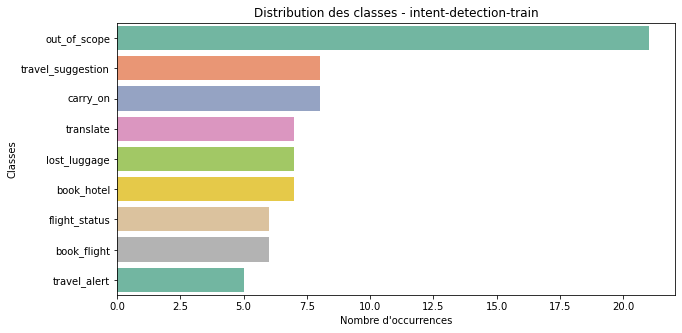

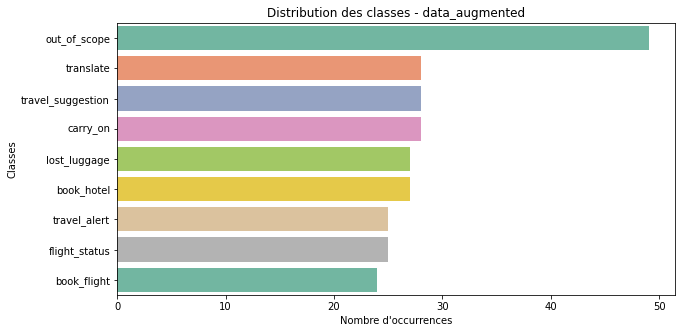

In [8]:


def plot_class_distribution(df, name):
    plt.figure(figsize=(10, 5))
    sns.countplot(y=df["label"], order=df["label"].value_counts().index, palette="Set2")
    plt.title(f"Distribution des classes - {name}")
    plt.xlabel("Nombre d'occurrences")
    plt.ylabel("Classes")
    plt.show()

plot_class_distribution(df1, "intent-detection-train")
plot_class_distribution(df2, "data_augmented")


# Longueur des textes

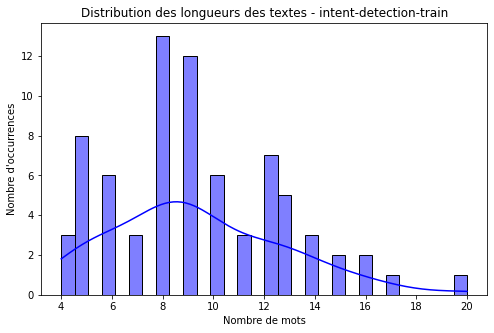

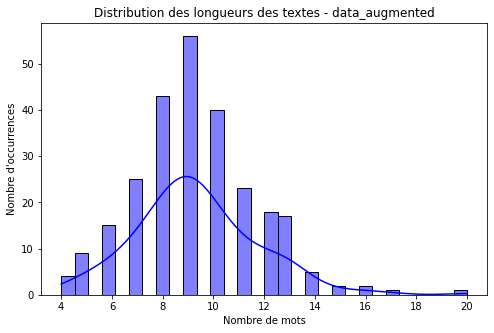

In [9]:


def plot_text_length(df, name):
    df["text_length"] = df["text"].apply(lambda x: len(str(x).split()))
    plt.figure(figsize=(8, 5))
    sns.histplot(df["text_length"], bins=30, kde=True, color='blue')
    plt.title(f"Distribution des longueurs des textes - {name}")
    plt.xlabel("Nombre de mots")
    plt.ylabel("Nombre d'occurrences")
    plt.show()

plot_text_length(df1, "intent-detection-train")
plot_text_length(df2, "data_augmented")


# Mots les plus fréquents

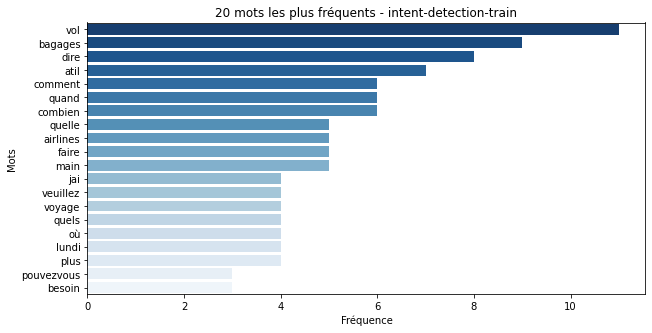

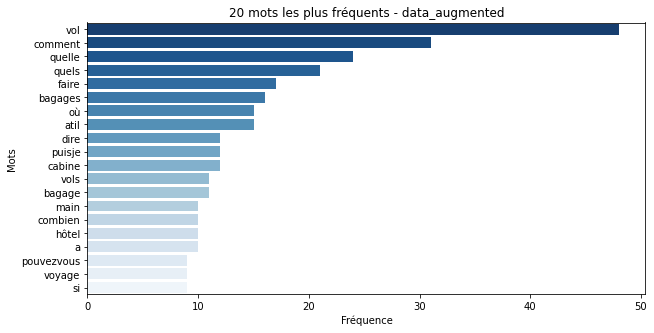

In [10]:


def preprocess_text(text):
    text = str(text).lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = " ".join([word for word in text.split() if word not in stop_words])
    return text

def plot_most_common_words(df, name, n=20):
    all_words = " ".join(df["text"].dropna().apply(preprocess_text)).split()
    counter = Counter(all_words)
    common_words = counter.most_common(n)
    words, counts = zip(*common_words)
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(counts), y=list(words), palette="Blues_r")
    plt.title(f"{n} mots les plus fréquents - {name}")
    plt.xlabel("Fréquence")
    plt.ylabel("Mots")
    plt.show()

plot_most_common_words(df1, "intent-detection-train")
plot_most_common_words(df2, "data_augmented")
